<a href="https://colab.research.google.com/github/KoonSH17/mids_datasci207/blob/main/07_Decision_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 7

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional note:

* You can complete this assignment using either your local machine or Google Colab. Your solution for this assignment should be able to run on the <span style="color:red">FREE version</span> of Google Colab. If you find that you need to upgrade to the paid version, it indicates that there is an inefficiency in your code.
---

#### ``Objectives``
1. Implement a Decision Forest for land cover classification

#### ``Motivation``

Land cover classification using machine learning (ML) techniques is important for several reasons, spanning environmental monitoring, resource management, urban planning, disaster response, and scientific research.

#### ``Data``

In this assignment, you will use the EuroSAT dataset, consisting of Sentinel-2 RGB satellite images of 10 classes with 27000 labeled and geo-referenced samples.

The dataset is hosted by [TensorFlow Data Collections](https://www.tensorflow.org/datasets/catalog/eurosat). To avoid any data versioning issues, we have downloaded the data for you (please see below).

`Download` link: [images + labels](https://drive.google.com/file/d/131GuYn092OlWKGopsT8arQoDreneU7SZ/view?usp=share_link). Once you unzip the file, you will see that the name of each subfolder represents the land cover classes.

---

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning.

# FILL IN CODE HERE #
!unzip /EuroSAT.zip -d ./ # Upzip dataset zip file
DATA_PATH = "./EuroSAT"

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

Streaming output truncated to the last 5000 lines.
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_2494.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_2494.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_2480.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_2480.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_292.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_292.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_1189.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_1189.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_1837.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_1837.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_2496.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_2496.jpg  
  inflating: ./EuroSAT/PermanentCrop/PermanentCrop_284.jpg  
  inflating: ./__MACOSX/EuroSAT/PermanentCrop/._PermanentCrop_284.jpg  
  inflat

^ make sure to replace DATA_PATH with the path to the directory where you saved the data.

---
### Step 1: Data ingestion

#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Let's load the 2D images and their corresponding labels. Implement the <span style="color:chocolate">load_data()</span> function below according to the following guidelines:
- to read label and image names: use the <span style="color:chocolate">os</span> library (in particular the <span style="color:chocolate">os.listdir()</span> and <span style="color:chocolate">os.path.join()</span> methods);
- to load an image: use the <span style="color:chocolate">load_image()</span> method (see list of imported libraries);
- to transform images to arrays: use the <span style="color:chocolate">img_to_array()</span> method (see list of imported libraries).

In [2]:
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data

    Returns:
    images (np.ndarray): A numpy array of shape (N, 64, 64, 3)
    labels (np.ndarray): A numpy array of shape (N)

    '''
    ## load images and labels
    # FILL IN CODE HERE #
    all_images = []
    all_labels = []

    # Get list of class directories
    class_names = sorted(os.listdir(path_to_data))

    for class_name in class_names:
        class_path = os.path.join(path_to_data, class_name)
        if os.path.isdir(class_path):
            for image_file in os.listdir(class_path):
                image_path = os.path.join(class_path, image_file)
                # Load image using keras_preprocessing.image.load_img
                img = load_img(image_path, target_size=(64, 64))
                # Convert image to numpy array
                img_array = img_to_array(img)
                all_images.append(img_array)
                all_labels.append(class_name)

    images = np.array(all_images)
    labels = np.array(all_labels)

    return images, labels

In [3]:
# Load images and labels. Print shapes

images, labels = load_data(DATA_PATH)
print("Shape of images ", images.shape)
print("Shape of labels ", labels.shape)

Shape of images  (27000, 64, 64, 3)
Shape of labels  (27000,)


---
### Step 2: Exploratory data analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot the land cover class distribution. Are the classes balanced?

Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

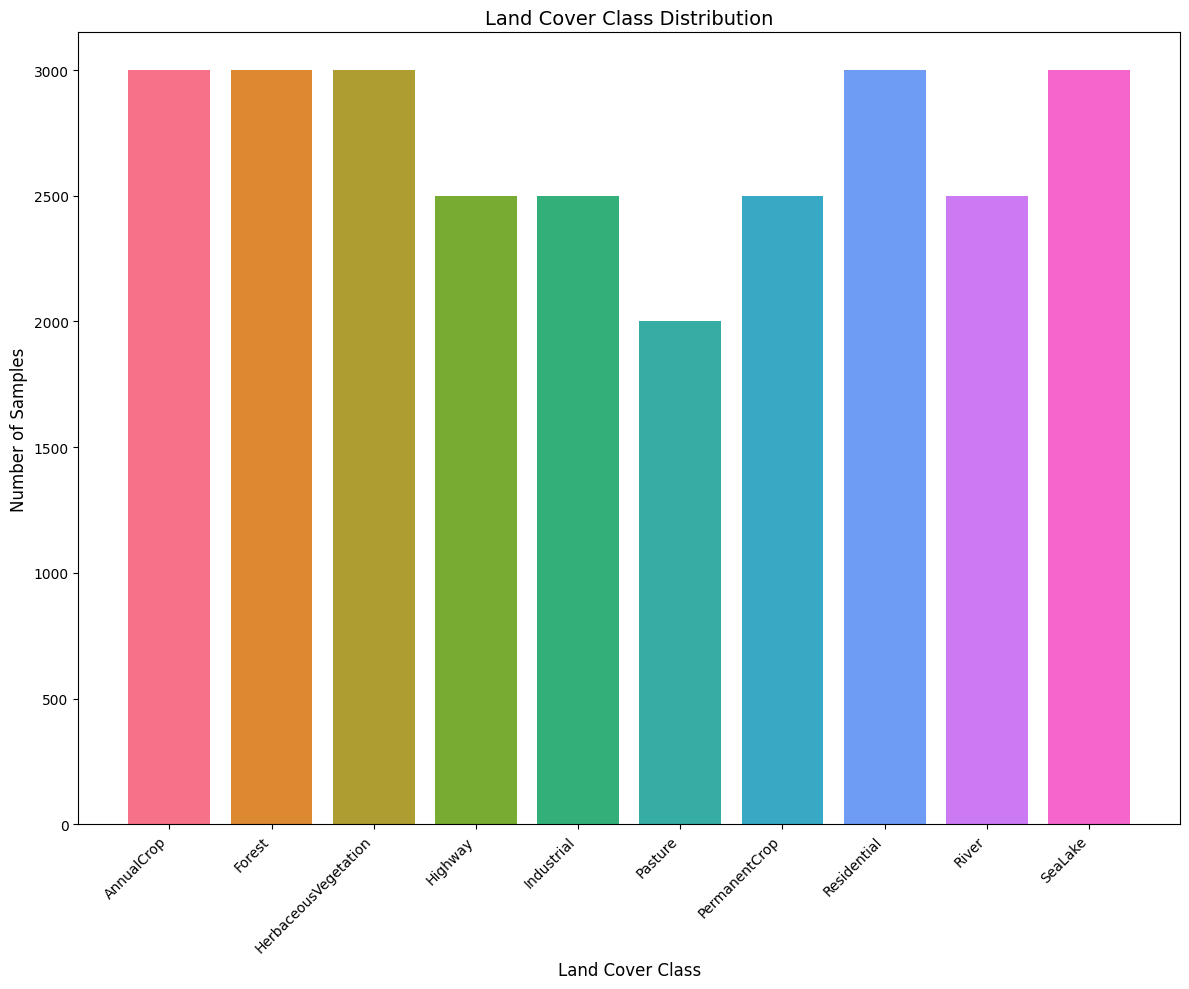

In [4]:
# FILL IN CODE HERE #
# Plot land cover class distribution
unique_classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12, 10))
bars = plt.bar(unique_classes, counts, color=sns.color_palette("husl", len(unique_classes)))
plt.title("Land Cover Class Distribution", fontsize=14)
plt.xlabel("Land Cover Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Comment on class balance: The EuroSAT dataset is balanced. Most classes contain around 2,000 – 3,000 samples, with no class dramatically over- or under-represented. Because of this balance, accuracy is a reliable evaluation metric so we don't need to worry about the model being biased toward a majority class.
It is acceptable to plot the class distribution before the train/val/test split because we are only observing the label counts, not making any modeling decisions based on them. The test set's "blindness" refers to it not influencing model training or hyperparameter selection hence inspecting global label frequencies doesn't violate that.

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Inspect (print) one image from each class. What land classes do you think a Decision Tree classifier is more likely to confuse?

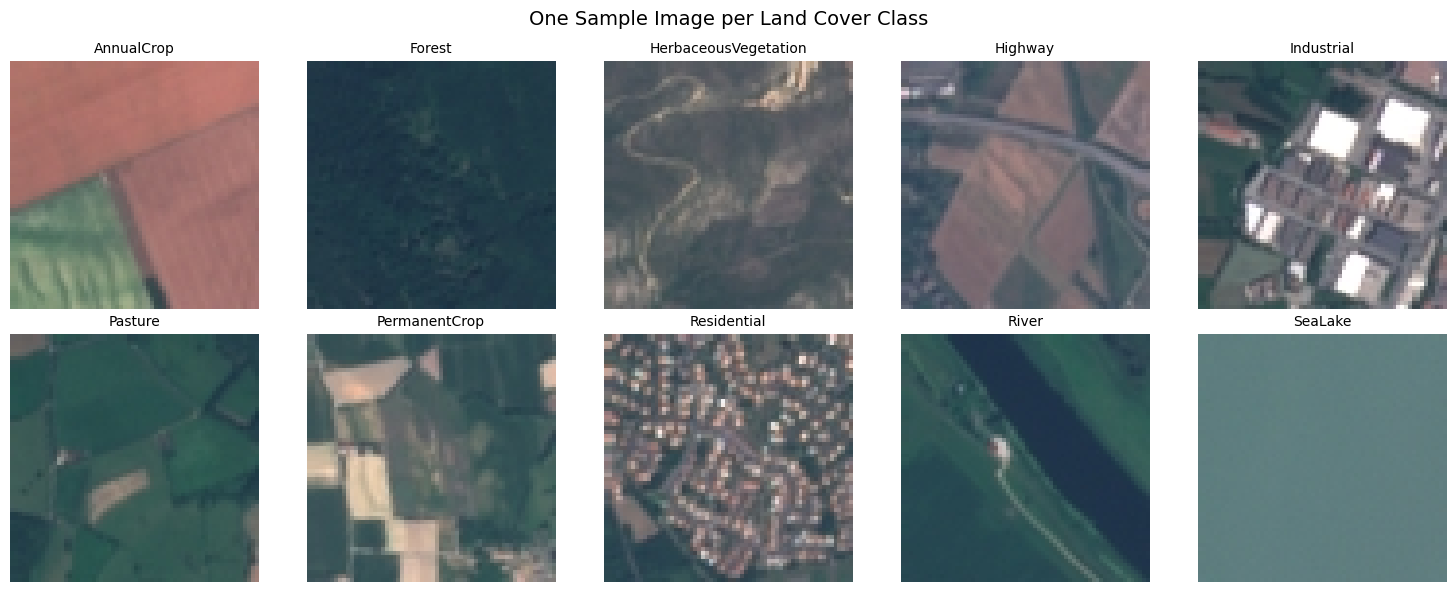

In [5]:
# FILL IN CODE HERE #
# Print one image from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, class_name in enumerate(unique_classes):
    idx = np.where(labels == class_name)[0][0]
    axes[i].imshow(images[idx].astype(np.uint8))
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

fig.suptitle("One Sample Image per Land Cover Class", fontsize=14)
plt.tight_layout()
plt.show()

Most confused land classes: A Decision Tree classifier is most likely to confuse classes that share similar pixel-level colour and texture statistics, since it operates on raw flattened pixel values without any spatial reasoning.
The highest-risk pairs are:

HerbaceousVegetation vs. Pasture: Both show similar green tones and unstructured terrain.

AnnualCrop vs. PermanentCrop: Both display patchwork field patterns with mixed greens and browns. The geometric layouts are similar enough to confuse.

Forest vs. Pasture: Both are dominated by dark greens, though Forest is noticeably darker and more uniform in texture.

---
### Step 3: Data preprocessing

Encode labels

In [6]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 9)
encoded_labels_classes = list(encoder.classes_) # store mapping generated by the encoder

#### <span style="color:chocolate"> Exercise 4 (10 points) </span>

Create train, validation, and test data. Implement the <span style="color:chocolate">split_data()</span> function below according to the following guidelines:
- shuffle images and labels before spliting the data;
- use a 60/20/20 split.

In [7]:
def split_data(images, labels, split):
    '''Split data into train, validation and test sets.

    Parameters:
    images  (np.ndarray): Images of shape (N, 64, 64, 3)
    labels (np.ndarray): Labels of shape (N,)
    split (tuple): 3 values summing to 1 defining split of train, validation and test sets

    Returns:
    X_train (np.ndarray): Train images of shape (N_train, 64, 64, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 64, 64, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 64, 64, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)

    '''
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator
    tf.random.set_seed(1234)
    np.random.seed(1234)

    # shuffle data
    # FILL IN CODE HERE #
    shuffle = tf.random.shuffle(tf.range(tf.shape(images)[0], dtype=tf.int32))
    images = tf.gather(images, shuffle).numpy()
    labels = tf.gather(labels, shuffle).numpy()

    # create data splits
    # FILL IN CODE HERE #
    n = len(images)
    n_train = int(split[0] * n)
    n_val = int(split[1] * n)

    X_train = images[:n_train]
    y_train = labels[:n_train]

    X_val = images[n_train:n_train + n_val]
    y_val = labels[n_train:n_train + n_val]

    X_test = images[n_train + n_val:]
    y_test = labels[n_train + n_val:]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [8]:
# define splits
split = (0.6, 0.2, 0.2)

# create train, val, test sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (16200, 64, 64, 3)
Shape of train labels  (16200,)
Shape of val images  (5400, 64, 64, 3)
Shape of train labels  (5400,)
Shape of test images  (5400, 64, 64, 3)
Shape of test labels  (5400,)


#### <span style="color:chocolate"> Exercise 5 (10 points) </span>

Perform image transformation and augmentation.

<span style="color:green"> Step 1: </span> Implement the <span style="color:chocolate">data_preprocessing()</span> function below according to the following guidelines:

- Applied on training set only:
    - create additional copies of the training images by applying the following augmentation techniques to each image: adjust brightness by adding DELTA=0.3 to the pixel values, then adjust contrast to CONTRAST_FACTOR=3, then flip left right (Hint: use the methods available in the tf.image module);
    - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 32400 images and labels;
    
    
- Applied on training, validation, and test sets: normalize all pixel values by dividing by 255.0.
    
<span style="color:green"> Step 2: </span> Comment on the importance of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well).

In [9]:
def data_preprocessing(X, y, data_partition='train'):
    '''Apply transformations and augmentations to training, validation, and test dat;

    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    data_partition (str): "train"

    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)

    '''

    CONTRAST_FACTOR = 3
    DELTA = 0.3

    # image augmentation on training data
    if data_partition=="train":
        # adjust brightness
        X_augm = tf.image.adjust_brightness(X, delta=DELTA)

        # adjust contrast
        X_augm = tf.image.adjust_contrast(X_augm, contrast_factor=CONTRAST_FACTOR)

        # random flip
        X_augm = tf.image.random_flip_left_right(X_augm)

        # concatenate original X and augmented X_aug data
        X = tf.concat([X, X_augm],axis=0)

        # concatenate y_train (note the label is preserved)
        y_augm = y
        y = tf.concat([y, y_augm],axis=0)

        # shuffle X and y, i.e., shuffle two tensors in the same order
        shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
        X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
        y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor


    # rescale image by dividing each pixel by 255.0
    X = X / 255.0

    return X, y

Comment on the importnace of adding augmented images to training data (be sure to justify why you don't augment the validation and test sets as well):
Data augmentation artificially expands the training set by creating realistic variations of existing images, helping the model learn features that are invariant to brightness, contrast, and orientation. This reduces overfitting and improves generalization. We don't augment the validation and test sets because they are meant to simulate real-world unseen data, augmenting them would give a distorted picture of how the model actually performs in deployment.

In [10]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

Shape of train images  (32400, 64, 64, 3)
Shape of train labels  (32400,)
Shape of val images  (5400, 64, 64, 3)
Shape of test images  (5400, 64, 64, 3)


Reshape training, val, and test data (to be compatible with sklearn Decision Forests)

In [11]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features used for Decision Forests', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features used for Decision Forests 12288
Shape of train images  (32400, 12288)
Shape of train labels  (32400,)
Shape of val images  (5400, 12288)
Shape of test images  (5400, 12288)


---
### Step 4: Modeling

#### <span style="color:chocolate"> Exercise 6 (10 points) </span>

Implement a Decision Forest classifier according to the following guidelines (let's call this model our baseline classifier):
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> class available in the <span style="color:chocolate">sklearn.ensemble</span> module;
- Set the following argument values:
    - n_estimators=2,
    - n_jobs=1
    - random_state=7
    - max_depth=8
- Train the model on (X_train_re, y_train) data;
- Evaluate the accuracy of the model on (X_train_re, y_train) and (X_val_re, y_val) data. Comment on model performance on training vs. validation datasets. Does the model generalize well?
- Plot the confusion matrix using (y_val, y_val_pred) data. Comment on the classes that the model confuses the most.

Train accuracy: 0.4825
Validation accuracy: 0.4489


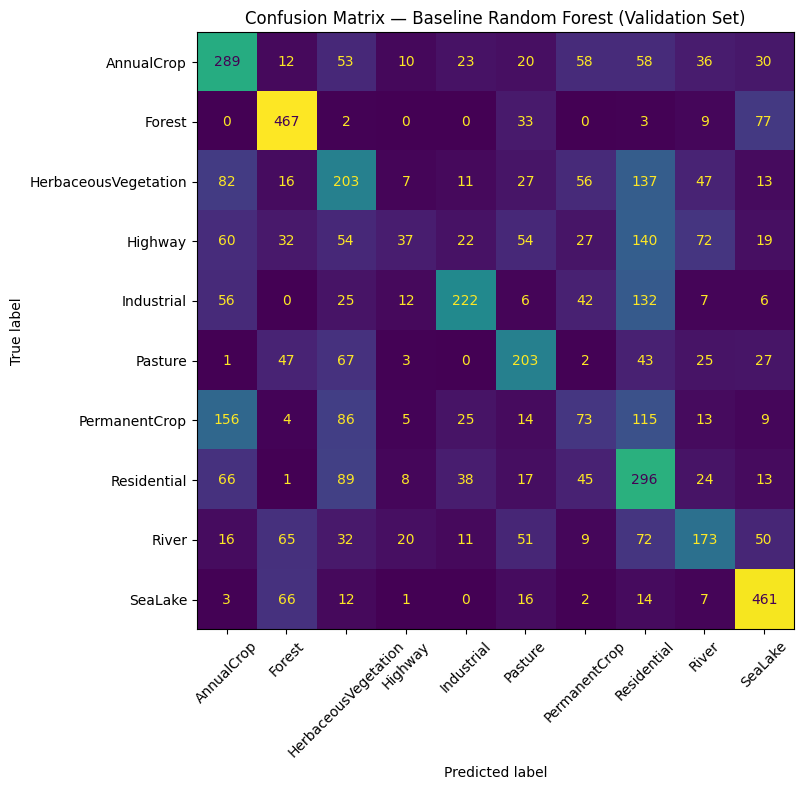

In [18]:
### YOUR CODE HERE ###
# Train baseline Random Forest classifier
rf_clf = ensemble.RandomForestClassifier(n_estimators=2, n_jobs=1, random_state=7, max_depth=8)
rf_clf.fit(X_train_re, y_train)

# Evaluate accuracy on train and validation sets
train_acc = accuracy_score(y_train, rf_clf.predict(X_train_re))
val_acc = accuracy_score(y_val, rf_clf.predict(X_val_re))

print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

# Plot confusion matrix
y_val_pred = rf_clf.predict(X_val_re)
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoded_labels_classes)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix — Baseline Random Forest (Validation Set)")
plt.tight_layout()
plt.show()

Comment on model accuracy on training vs. validation data: Train accuracy is 0.4825 and validation accuracy is 0.4489 — a small gap of ~3%, so the model is not significantly overfitting. However, both values are quite low, meaning the baseline model simply lacks the capacity to classify well with only 2 trees at max_depth=8.

Does the model generalize well?: The train-val gap is small, so it generalizes consistently

Comment on the classes that the model confuses the most: The confusion matrix confirms the earlier predictions partially. The worst-performing classes are Highway (only 37 correct, heavily confused with Residential and HerbaceousVegetation) and PermanentCrop (115 correct, heavily confused with AnnualCrop). Surprisingly, Forest and SeaLake perform well despite being confused with each other (Forest to SeaLake: 77, SeaLake to Forest: 66), likely because their overall pixel distributions are still distinct enough for the shallow trees to separate them from other classes.

#### <span style="color:chocolate"> Exercise 7 (20 points) </span>

Implement a Decision Forest classifier that improves the training and validation set accuracy performance of the baseline model implemented above by at least 10% (the more you can improve the better). Also, the performance difference between the training and validation sets should be at most 10%. Be sure to follow these guidelines:
    
- Use the <span style="color:chocolate">RandomForestClassifier</span> or the <span style="color:chocolate">GradientBoostingClassifier</span> available in the <span style="color:chocolate">sklearn.ensemble</span> module
- Be explicit on how your implementation is different compared to the baseline classifier:
    - different argment values for the baseline model (RandomForestClassifier)?
    - different Decision Forest classifier?
    - different data preprocessing procedure?
    - a combination of the three points above
    - anything else?
- Train the model on (X_train_re, y_train) data.
- Evaluate the model's accuracy on (X_val_re, y_val) data. Comment on training vs. validation performance relative to baseline model.
- Plot confusion matrix using the (y_val, y_val_pred) data. Comment on the classes the model confuses the most relative to the baseline.

Train accuracy: 0.6275
Validation accuracy: 0.5528


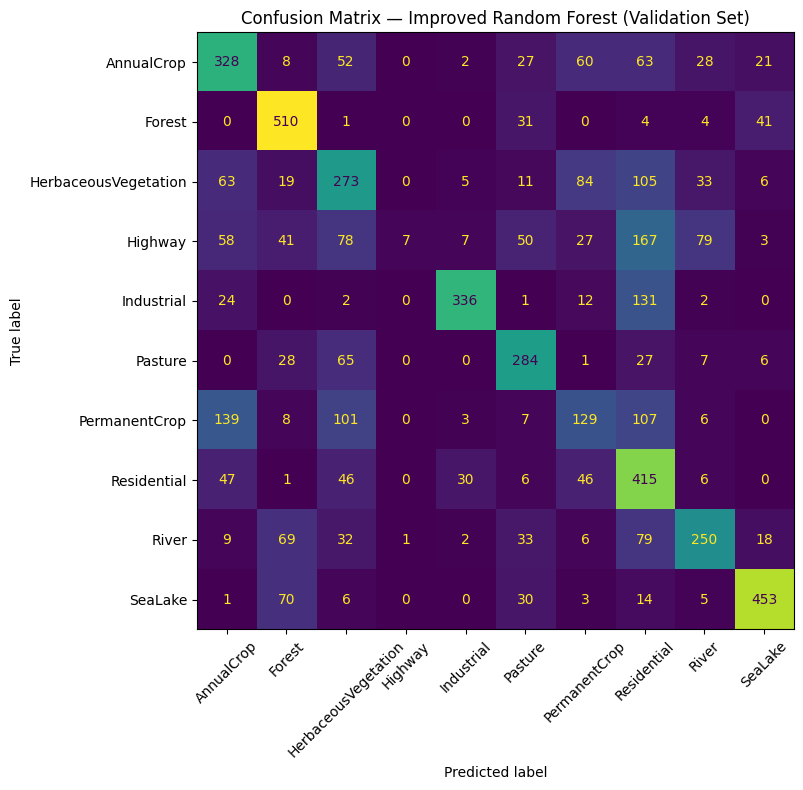

In [37]:
### YOUR CODE HERE ###
# Improved Random Forest argment values
rf_clf2 = ensemble.RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=8, min_samples_leaf=15)
rf_clf2.fit(X_train_re, y_train)

# Evaluate accuracy
train_acc2 = accuracy_score(y_train, rf_clf2.predict(X_train_re))
val_acc2 = accuracy_score(y_val, rf_clf2.predict(X_val_re))

print(f"Train accuracy: {train_acc2:.4f}")
print(f"Validation accuracy: {val_acc2:.4f}")

# Confusion matrix
y_val_pred2 = rf_clf2.predict(X_val_re)
cm2 = confusion_matrix(y_val, y_val_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=encoded_labels_classes)

fig, ax = plt.subplots(figsize=(10, 8))
disp2.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix — Improved Random Forest (Validation Set)")
plt.tight_layout()
plt.show()

How your implementation is different compared to the baseline classifier:

n_estimators: 2 → 100, giving a much larger ensemble that reduces variance through averaging

min_samples_leaf: addded new argment which forces each leaf to represent at least 15 samples, preventing overly specific splits

n_jobs=-1 to use all CPU cores for faster training

Comment on training vs. validation performance relative to baseline model: B

Both train and validation accuracy improved significantly over the baseline. The train-validation gap is 7.5%, well within the ≤10% requirement, meaning the model generalizes more consistently than the baseline despite the higher accuracy.

Comment on the classes the model confuses the most relative to the baseline:

The overall confusion pattern is similar but less severe. Highway remains the hardest class, heavily confused with Residential (167) and HerbaceousVegetation (78).

PermanentCrop is still frequently misclassified as AnnualCrop (139) and HerbaceousVegetation (101).

---
### Step 5: Evaluation and Generalization

#### <span style="color:chocolate"> Exercise 8 (2 points) </span>

Report accuracy performance on the test data using the model trained for Exercise 7. How does the test set performance compare with the one reported for the training and validation sets?

In [38]:
### YOUR CODE HERE ###
test_acc2 = accuracy_score(y_test, rf_clf2.predict(X_test_re))
print(f"Test accuracy: {test_acc2:.4f}")

Test accuracy: 0.5496


Comment on test set accuracy vs. training vs. validation set accuracy:

This accuracy is consistent across all three sets that is training (0.6275), validation (0.5528), test (0.5496). This confirms that the model generalizes well to unseen data and is not overfitting to the validation set. The small train-val-test gap suggests the 60/20/20 split produced representative subsets of the overall data distribution.

---
### Step 6: Discussion

#### <span style="color:chocolate"> Exercise 9 (8 points) </span>

Would you recommend a Decision Forest for land cover classification? Why or why not?

In [40]:
### YOUR ANSWER HERE ###

A Decision Forest is a reasonable baseline for land cover classification but not the recommended final approach. On the positive side, it is easy to train, requires minimal hyperparameter tuning, and is interpretable in terms of feature importance. It also handles multiclass classification natively and trains relatively fast compared to deep learning models.
However, the ~55% validation accuracy achieved here highlights its core limitation: it operates on raw flattened pixel values, treating each pixel independently without any understanding of spatial structure or local patterns. Land cover classification inherently relies on texture, shape, and spatial context, all informations that a decision forest cannot capture when pixels are simply concatenated into a 1D feature vector. Classes like Highway and PermanentCrop that require spatial reasoning to distinguish remain poorly classified as a result.

#### <span style="color:chocolate"> Exercise 10 (10 points) </span>

What other ML model would you propose to improve performance over the Decision Forest classifier you implemented for Exercise 7?

In [16]:
### YOUR ANSWER HERE ###

A Convolutional Neural Network (CNN) would be the most suitable model to improve over the Decision Forest classifier. Unlike a Random Forest which operates on flattened raw pixel values, a CNN applies learned convolutional filters that detect local spatial patterns such as edges, textures, and shapes.
These features are critical for distinguishing land cover classes like Highway, PermanentCrop, and HerbaceousVegetation.

Specifically, a CNN with the following architecture would be appropriate:
- Multiple convolutional + max-pooling layers to extract hierarchical spatial features at increasing levels of abstraction
- Batch normalisation layers to stabilise training
- Dropout layers to prevent overfitting
- A fully connected output layer with softmax activation for 10-class classification

The key advantage is that CNNs preserve and exploit the 2D spatial structure of the images (64×64×3) rather than discarding it through flattening, which is the fundamental bottleneck of the Decision Forest approach.

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Implement the idea proposed for Exercise 10. Perform hyperparameter tuning using the training and validation sets, then report the model performance on the test data. Does your model generalize well?

In [17]:
### YOUR CODE HERE ###